# 05 Analysis: Generative AI and Data Analyst Job Requirements

This notebook cleans the 51job data, constructs AI-skill and traditional-skill measures, creates descriptive figures, and estimates baseline regression models for the MGS 3001 final project.

## Setup note

If any package import fails, run this once in a notebook cell before the imports:

```python
%pip install pandas numpy matplotlib seaborn statsmodels
```


In [1]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

warnings.filterwarnings("ignore")

# Use seaborn's default font stack to avoid platform-specific font warnings.
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["axes.unicode_minus"] = False

DATA_PATH = Path("../data/51job_cleaned.csv")
OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(exist_ok=True)


In [2]:
df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
df = df.rename(columns={
    "标题": "title",
    "标题链接": "job_url",
    "sal": "salary_raw",
    "er": "company",
    "er1": "company_type",
    "字段1": "company_size",
    "抓取时间": "scrape_time",
    "职位信息_全文": "job_text",
})
df.head()

,title,job_url,salary_raw,company,company_type,company_size,scrape_time,job_text
0,KD项目包装数据库专员,https://jobs.51job.com/shanghai-ypq/171924257....,1-1.3万·14薪,安吉天地物流科技,民营,少于50人,2026-05-12 18:49:19,1、完成KD项目每个车型包装数据测算，跟踪实际与测算差异并给出差异原因\r\n2、完成KD项...
1,数据分析师,https://jobs.51job.com/shanghai-pdxq/171811813...,1-1.5万·13薪,上海学获帮教育科技,民营,NaN,2026-05-12 18:49:19,【工作内容】\r\n- 负责公司业务数据的收集、清洗和分析，提供数据支持决策；\r\n- 搭...
2,数据分析师,https://jobs.51job.com/shanghai/170740993.html...,9千-1.3万,上海塑盛电子商务,民营,少于50人,2026-05-12 18:49:19,【工作内容】\r\n- 负责公司业务数据的收集、清洗与分析，提供数据支持决策；\r\n- 利...
3,优化工程师（数据分析方向）,https://jobs.51job.com/shanghai/156229312.html...,1.3-2.5万,上海吉祥航空,民营,5000-10000人,2026-05-12 18:49:19,岗位职责:\r\n1. 负责根据公司战略需要，对公司运行管理优化（OPT）的管理机制进行建设...
4,数据分析师-有经验者优先,https://jobs.51job.com/beijing/171125653.html?...,1.2-2.3万,上海学获帮教育科技,民营,NaN,2026-05-12 18:49:19,【工作内容】\r\n- 负责公司业务数据的收集、清洗、分析及可视化，为业务决策提供数据支持；...


In [3]:
def extract_city(url):
    text = str(url).lower()
    if "beijing" in text:
        return "Beijing"
    if "shanghai" in text:
        return "Shanghai"
    if "guangzhou" in text:
        return "Guangzhou"
    if "shenzhen" in text:
        return "Shenzhen"
    return "Other"

df["city"] = df["job_url"].map(extract_city)
print(df["city"].value_counts(dropna=False))

# Keep only the four target cities for the final project analysis.
df = df[df["city"].isin(["Beijing", "Shanghai", "Guangzhou", "Shenzhen"])].copy()
df.shape

city
Shanghai     387
Guangzhou    158
Shenzhen     128
Beijing      124
Other          8
Name: count, dtype: int64


(797, 9)

In [4]:
def parse_salary_monthly(raw):
    # Parse 51job salary strings into monthly low/high/midpoint and annualized midpoint.
    # The final salary regression keeps monthly salary postings only. Daily/hourly salaries,
    # negotiable salaries, and missing salaries are coded as NaN for regression use.
    if pd.isna(raw):
        return pd.Series([np.nan, np.nan, np.nan, np.nan, "missing"])
    s = str(raw).strip().replace(" ", "")
    if not s or "面议" in s:
        return pd.Series([np.nan, np.nan, np.nan, np.nan, "negotiable"])
    if "元/天" in s or "元/日" in s or "元/小时" in s:
        return pd.Series([np.nan, np.nan, np.nan, np.nan, "daily_or_hourly"])

    multiplier = 12
    m_mult = re.search(r"·(\d+)薪", s)
    if m_mult:
        multiplier = int(m_mult.group(1))

    annual_salary = "年" in s and "万" in s
    nums = [float(x) for x in re.findall(r"\d+(?:\.\d+)?", s)]
    if not nums:
        return pd.Series([np.nan, np.nan, np.nan, np.nan, "unparsed"])
    low = nums[0]
    high = nums[1] if len(nums) > 1 else nums[0]

    if "千" in s or "k" in s.lower():
        low *= 1000
        high *= 1000
    elif "万" in s:
        low *= 10000
        high *= 10000

    if annual_salary:
        low /= 12
        high /= 12
        multiplier = 12

    mid = (low + high) / 2
    annualized = mid * multiplier
    return pd.Series([low, high, mid, annualized, "monthly"])

df[["salary_low", "salary_high", "salary_mid", "salary_annualized", "salary_parse_status"]] = df["salary_raw"].apply(parse_salary_monthly)

# Remove implausible monthly wages from regression sample only.
df["salary_valid"] = (
    (df["salary_parse_status"] == "monthly")
    & (df["salary_mid"] >= 3000)
    & (df["salary_mid"] <= 80000)
)
df["log_salary"] = np.where(df["salary_valid"], np.log(df["salary_mid"]), np.nan)
df["salary_parse_status"].value_counts(dropna=False)

salary_parse_status
monthly            745
daily_or_hourly     41
missing             11
Name: count, dtype: int64

In [ ]:

text = (df["title"].fillna("") + " " + df["job_text"].fillna("")).str.lower()

ai_terms = [
    "ai", "人工智能", "aigc", "chatgpt", "gpt", "大模型", "大型语言模型",
    "llm", "prompt", "提示词", "rag", "copilot", "机器学习", "machine learning",
    "深度学习", "deep learning", "自然语言处理", "nlp", "智能体", "agent"
]

advanced_ai_terms = [
    "大模型", "大型语言模型", "llm", "rag", "机器学习", "machine learning",
    "深度学习", "deep learning", "自然语言处理", "nlp"
]

traditional_skill_terms = {
    "sql": ["sql"],
    "python": ["python"],
    "excel": ["excel"],
    "bi_visualization": ["tableau", "power bi", "数据可视化", "可视化", "bi"],
    "big_data": ["spark", "hadoop", "etl"],
    "statistics_modeling": ["统计", "建模", "模型", "数据挖掘", "预测"],
    "database": ["数据库", "data warehouse", "数仓"],
}

def keyword_pattern(term):
    """Use word boundaries for English abbreviations to avoid matches inside other words."""
    escaped = re.escape(term.lower())
    if re.search(r"[a-z0-9]", term.lower()) and not re.search(r"[\u4e00-\u9fff]", term):
        return rf"(?<![a-z0-9]){escaped}(?![a-z0-9])"
    return escaped

for term in ai_terms:
    df[f"ai_{term}"] = text.str.contains(keyword_pattern(term), regex=True, na=False)

df["ai_skill"] = df[[f"ai_{term}" for term in ai_terms]].any(axis=1).astype(int)
df["ai_exposure_score"] = df[[f"ai_{term}" for term in ai_terms]].sum(axis=1)
df["advanced_ai_skill"] = df[[f"ai_{term}" for term in advanced_ai_terms]].any(axis=1).astype(int)

for group, terms in traditional_skill_terms.items():
    pattern = "|".join(keyword_pattern(t) for t in terms)
    df[f"skill_{group}"] = text.str.contains(pattern, regex=True, na=False).astype(int)

skill_cols = [f"skill_{group}" for group in traditional_skill_terms]
df["traditional_skill_count"] = df[skill_cols].sum(axis=1)

df[["ai_skill", "advanced_ai_skill", "ai_exposure_score", "traditional_skill_count"]].describe()


In [6]:
summary = {
    "n_rows": len(df),
    "salary_valid_n": int(df["salary_valid"].sum()),
    "ai_skill_n": int(df["ai_skill"].sum()),
    "ai_skill_share": float(df["ai_skill"].mean()),
}
summary

{'n_rows': 797,
 'salary_valid_n': 743,
 'ai_skill_n': 292,
 'ai_skill_share': 0.36637390213299875}

In [7]:
city_summary = (
    df.groupby("city")
    .agg(
        postings=("title", "size"),
        ai_skill_share=("ai_skill", "mean"),
        valid_salary_n=("salary_valid", "sum"),
        median_salary=("salary_mid", "median"),
        mean_traditional_skill_count=("traditional_skill_count", "mean"),
    )
    .sort_values("postings", ascending=False)
)
city_summary

,postings,ai_skill_share,valid_salary_n,median_salary,mean_traditional_skill_count
city,,,,,
Shanghai,387,0.400517,357,12500.0,2.674419
Guangzhou,158,0.392405,148,12000.0,2.721519
Shenzhen,128,0.289062,126,8250.0,2.812500
Beijing,124,0.306452,112,12500.0,2.500000


In [8]:
ai_term_counts = (
    pd.Series({term: int(df[f"ai_{term}"].sum()) for term in ai_terms}, name="postings")
    .sort_values(ascending=False)
)

skill_display_names = {
    "skill_sql": "SQL",
    "skill_python": "Python",
    "skill_excel": "Excel",
    "skill_bi_visualization": "BI / visualization",
    "skill_big_data": "Big data",
    "skill_statistics_modeling": "Statistics / modeling",
    "skill_database": "Database",
}
skill_counts = (
    pd.Series({skill_display_names[col]: int(df[col].sum()) for col in skill_cols}, name="postings")
    .sort_values(ascending=False)
)

# Drop zero-count AI terms before plotting so labels never show as null/empty categories.
ai_term_counts_nonzero = ai_term_counts[ai_term_counts > 0]

display(ai_term_counts_nonzero)
display(skill_counts)


ai                  220
机器学习                 67
人工智能                 56
大模型                  41
rag                  29
深度学习                 27
machine learning     16
llm                  14
agent                13
智能体                  13
自然语言处理               11
prompt               10
nlp                  10
gpt                   9
deep learning         5
chatgpt               3
aigc                  2
提示词                   2
copilot               2
Name: postings, dtype: int64

Statistics / modeling    524
BI / visualization       386
Python                   362
SQL                      347
Excel                    334
Database                 125
Big data                  57
Name: postings, dtype: int64

## Final visualization set

The five figures below follow the required chart types for the final project.


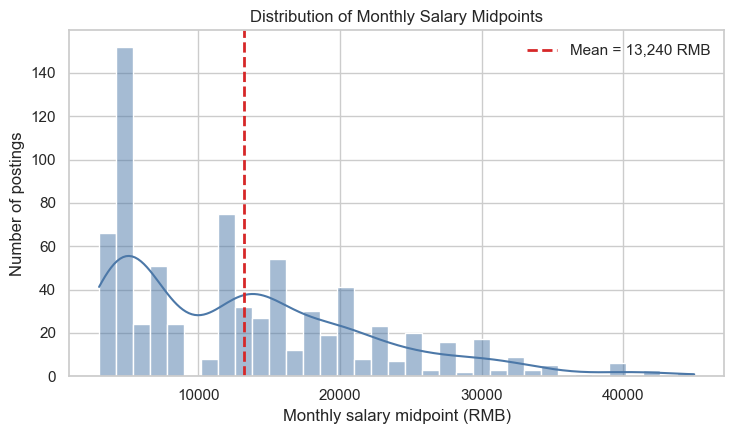

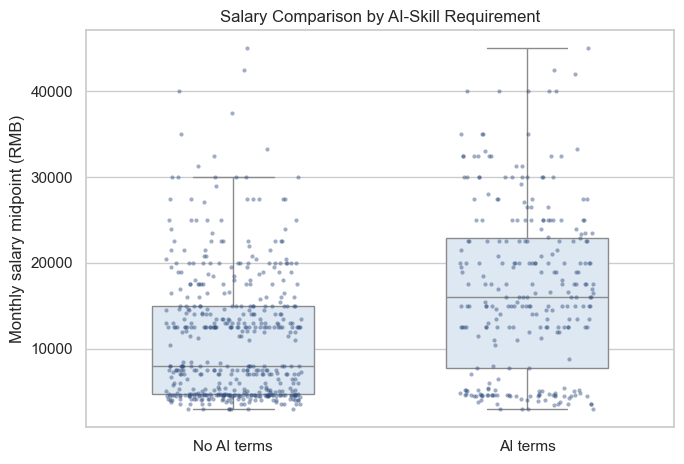

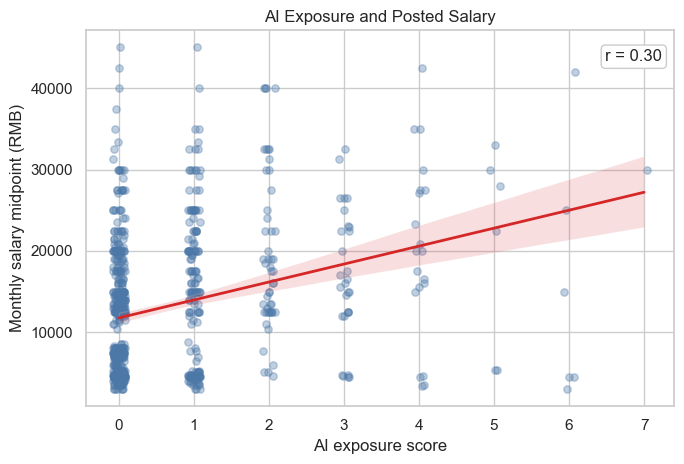

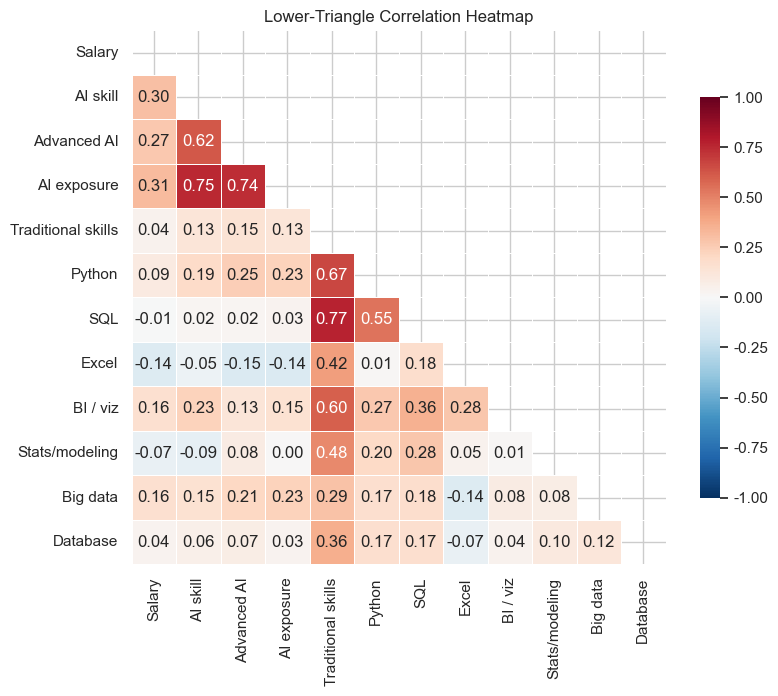

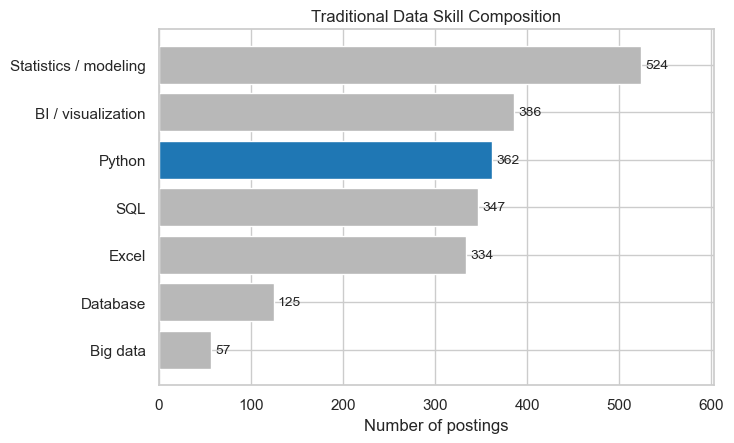

In [9]:
# Figure 1: Distribution - histogram + KDE + mean line
salary_df = df[df["salary_valid"]].copy()

fig, ax = plt.subplots(figsize=(7.5, 4.5))
sns.histplot(data=salary_df, x="salary_mid", bins=35, kde=True, color="#4C78A8", edgecolor="white", ax=ax)
mean_salary = salary_df["salary_mid"].mean()
ax.axvline(mean_salary, color="#D62728", linestyle="--", linewidth=2, label=f"Mean = {mean_salary:,.0f} RMB")
ax.set_title("Distribution of Monthly Salary Midpoints")
ax.set_xlabel("Monthly salary midpoint (RMB)")
ax.set_ylabel("Number of postings")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig1_salary_distribution_hist_kde.png", dpi=220)
plt.show()

# Figure 2: Group comparison - boxplot + stripplot showing raw points
fig, ax = plt.subplots(figsize=(7, 4.8))
sns.boxplot(data=salary_df, x="ai_skill", y="salary_mid", color="#D9E8F5", width=0.55, fliersize=0, ax=ax)
sns.stripplot(data=salary_df, x="ai_skill", y="salary_mid", color="#2F4B7C", alpha=0.45, jitter=0.23, size=3, ax=ax)
ax.set_xticklabels(["No AI terms", "AI terms"])
ax.set_title("Salary Comparison by AI-Skill Requirement")
ax.set_xlabel("")
ax.set_ylabel("Monthly salary midpoint (RMB)")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig2_salary_by_ai_box_strip.png", dpi=220)
plt.show()

# Figure 3: Relationship - regression scatter with correlation annotation
rel_df = salary_df[["ai_exposure_score", "salary_mid"]].dropna().copy()
r = rel_df["ai_exposure_score"].corr(rel_df["salary_mid"])
fig, ax = plt.subplots(figsize=(7, 4.8))
sns.regplot(
    data=rel_df,
    x="ai_exposure_score",
    y="salary_mid",
    x_jitter=0.08,
    scatter_kws={"alpha": 0.35, "s": 28, "color": "#4C78A8"},
    line_kws={"color": "#D62728", "linewidth": 2},
    ax=ax,
)
ax.text(0.98, 0.95, f"r = {r:.2f}", transform=ax.transAxes, ha="right", va="top", fontsize=12,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="#CCCCCC"))
ax.set_title("AI Exposure and Posted Salary")
ax.set_xlabel("AI exposure score")
ax.set_ylabel("Monthly salary midpoint (RMB)")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig3_ai_exposure_salary_regplot.png", dpi=220)
plt.show()

# Figure 4: Multivariate correlation - lower-triangle heatmap
corr_vars = [
    "salary_mid", "ai_skill", "advanced_ai_skill", "ai_exposure_score",
    "traditional_skill_count", "skill_python", "skill_sql", "skill_excel",
    "skill_bi_visualization", "skill_statistics_modeling", "skill_big_data", "skill_database",
]
corr_df = df[corr_vars].copy()
corr_df = corr_df.rename(columns={
    "salary_mid": "Salary",
    "ai_skill": "AI skill",
    "advanced_ai_skill": "Advanced AI",
    "ai_exposure_score": "AI exposure",
    "traditional_skill_count": "Traditional skills",
    "skill_python": "Python",
    "skill_sql": "SQL",
    "skill_excel": "Excel",
    "skill_bi_visualization": "BI / viz",
    "skill_statistics_modeling": "Stats/modeling",
    "skill_big_data": "Big data",
    "skill_database": "Database",
})
corr = corr_df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(8.5, 7))
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, vmin=-1, vmax=1, annot=True, fmt=".2f",
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.75}, ax=ax)
ax.set_title("Lower-Triangle Correlation Heatmap")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig4_correlation_heatmap_lower_triangle.png", dpi=220)
plt.show()

# Figure 5: Composition - horizontal bar chart, highlight Python in blue and others gray
skill_plot = skill_counts.sort_values(ascending=True)
colors = ["#1F77B4" if skill == "Python" else "#B8B8B8" for skill in skill_plot.index]
fig, ax = plt.subplots(figsize=(7.5, 4.6))
ax.barh(skill_plot.index, skill_plot.values, color=colors)
ax.set_title("Traditional Data Skill Composition")
ax.set_xlabel("Number of postings")
ax.set_ylabel("")
for i, value in enumerate(skill_plot.values):
    ax.text(value + 4, i, f"{value}", va="center", fontsize=10)
ax.set_xlim(0, max(skill_plot.values) * 1.15)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig5_skill_composition_python_highlight.png", dpi=220)
plt.show()


In [10]:
reg_df = df[df["salary_valid"]].copy()
reg_df["company_type"] = reg_df["company_type"].fillna("Unknown")
reg_df["company_size"] = reg_df["company_size"].fillna("Unknown")

model1 = smf.ols("log_salary ~ ai_skill + C(city) + C(company_type) + C(company_size)", data=reg_df).fit(cov_type="HC1")
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:             log_salary   R-squared:                       0.170
Model:                            OLS   Adj. R-squared:                  0.146
Method:                 Least Squares   F-statistic:                     33.27
Date:                Tue, 19 May 2026   Prob (F-statistic):           2.19e-85
Time:                        18:20:58   Log-Likelihood:                -716.72
No. Observations:                 743   AIC:                             1477.
Df Residuals:                     721   BIC:                             1579.
Df Model:                          21                                         
Covariance Type:                  HC1                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

In [11]:
skill_df = df.copy()
skill_df["company_type"] = skill_df["company_type"].fillna("Unknown")
skill_df["company_size"] = skill_df["company_size"].fillna("Unknown")

model2 = smf.ols("traditional_skill_count ~ ai_skill + C(city) + C(company_type) + C(company_size)", data=skill_df).fit(cov_type="HC1")
print(model2.summary())

                               OLS Regression Results                              
Dep. Variable:     traditional_skill_count   R-squared:                       0.082
Model:                                 OLS   Adj. R-squared:                  0.055
Method:                      Least Squares   F-statistic:                     56.08
Date:                     Tue, 19 May 2026   Prob (F-statistic):          1.13e-139
Time:                             18:20:58   Log-Likelihood:                -1498.3
No. Observations:                      797   AIC:                             3043.
Df Residuals:                          774   BIC:                             3150.
Df Model:                               22                                         
Covariance Type:                       HC1                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------

In [ ]:

# Robustness checks: add controls step by step to show whether the AI-salary association is stable.
model_salary_no_controls = smf.ols("log_salary ~ ai_skill", data=reg_df).fit(cov_type="HC1")
model_salary_city = smf.ols("log_salary ~ ai_skill + C(city)", data=reg_df).fit(cov_type="HC1")
model_salary_full = model1
model_salary_city_interaction = smf.ols(
    "log_salary ~ ai_skill * C(city) + C(company_type) + C(company_size)",
    data=reg_df,
).fit(cov_type="HC1")

for name, model in [
    ("No controls", model_salary_no_controls),
    ("City controls", model_salary_city),
    ("Full controls", model_salary_full),
    ("City interaction", model_salary_city_interaction),
]:
    print(f"\n{name}")
    print(model.summary())


In [ ]:

def stars(p_value):
    if pd.isna(p_value):
        return ""
    if p_value < 0.001:
        return "***"
    if p_value < 0.01:
        return "**"
    if p_value < 0.05:
        return "*"
    return ""

def coef_with_stars(model, variable="ai_skill"):
    coef = model.params.get(variable, np.nan)
    p_value = model.pvalues.get(variable, np.nan)
    return f"{coef:.3f}{stars(p_value)}"

def se_in_parentheses(model, variable="ai_skill"):
    se = model.bse.get(variable, np.nan)
    return f"({se:.3f})"

coef_table = pd.DataFrame({
    "model": ["Model 1: Salary", "Model 2: Skill complementarity"],
    "dependent_variable": ["Log monthly salary midpoint", "Traditional skill count"],
    "key_variable": ["ai_skill", "ai_skill"],
    "coef": [model1.params.get("ai_skill", np.nan), model2.params.get("ai_skill", np.nan)],
    "std_error": [model1.bse.get("ai_skill", np.nan), model2.bse.get("ai_skill", np.nan)],
    "p_value": [model1.pvalues.get("ai_skill", np.nan), model2.pvalues.get("ai_skill", np.nan)],
    "significance": [stars(model1.pvalues.get("ai_skill", np.nan)), stars(model2.pvalues.get("ai_skill", np.nan))],
    "n": [int(model1.nobs), int(model2.nobs)],
    "r_squared": [model1.rsquared, model2.rsquared],
})
coef_table.to_csv(OUTPUT_DIR / "regression_key_results.csv", index=False, encoding="utf-8-sig")

paper_regression_table = pd.DataFrame({
    "Variable": ["AI skill", "", "Controls", "N", "R-squared"],
    "Model 1: Log salary": [
        coef_with_stars(model1),
        se_in_parentheses(model1),
        "City, company type, company size",
        f"{int(model1.nobs)}",
        f"{model1.rsquared:.3f}",
    ],
    "Model 2: Traditional skill count": [
        coef_with_stars(model2),
        se_in_parentheses(model2),
        "City, company type, company size",
        f"{int(model2.nobs)}",
        f"{model2.rsquared:.3f}",
    ],
})
paper_regression_table.to_csv(OUTPUT_DIR / "paper_table_regression.csv", index=False, encoding="utf-8-sig")

robustness_models = [
    ("No controls", model_salary_no_controls, "None"),
    ("City controls", model_salary_city, "City"),
    ("Full controls", model_salary_full, "City, company type, company size"),
]
robustness_table = pd.DataFrame({
    "Variable": ["AI skill", "", "Controls", "N", "R-squared"],
})
for i, (name, model, controls) in enumerate(robustness_models, start=1):
    robustness_table[f"Model {i}: {name}"] = [
        coef_with_stars(model),
        se_in_parentheses(model),
        controls,
        f"{int(model.nobs)}",
        f"{model.rsquared:.3f}",
    ]
robustness_table.to_csv(OUTPUT_DIR / "paper_table_salary_robustness.csv", index=False, encoding="utf-8-sig")

final_stats = {
    "n_raw": 805,
    "n_target_cities": int(len(df)),
    "n_excluded_other_city": 805 - int(len(df)),
    "salary_valid": int(df["salary_valid"].sum()),
    "salary_invalid": int((~df["salary_valid"]).sum()),
    "ai_n": int(df["ai_skill"].sum()),
    "ai_share": float(df["ai_skill"].mean()),
    "advanced_ai_n": int(df["advanced_ai_skill"].sum()),
    "advanced_ai_share": float(df["advanced_ai_skill"].mean()),
    "city_counts": {k: int(v) for k, v in df["city"].value_counts().to_dict().items()},
    "city_ai_share": {k: round(float(v), 4) for k, v in df.groupby("city")["ai_skill"].mean().to_dict().items()},
    "salary_by_ai": {
        str(k): {
            "count": int(v["count"]),
            "mean": round(float(v["mean"]), 2),
            "median": round(float(v["median"]), 2),
            "std": round(float(v["std"]), 2),
        }
        for k, v in salary_df.groupby("ai_skill")["salary_mid"].agg(["count", "mean", "median", "std"]).to_dict("index").items()
    },
    "skill_by_ai": {
        str(k): {
            "count": int(v["count"]),
            "mean": round(float(v["mean"]), 3),
            "median": round(float(v["median"]), 2),
            "std": round(float(v["std"]), 3),
        }
        for k, v in df.groupby("ai_skill")["traditional_skill_count"].agg(["count", "mean", "median", "std"]).to_dict("index").items()
    },
    "company_type_counts": {k: int(v) for k, v in df["company_type"].fillna("Unknown").value_counts().to_dict().items()},
    "company_size_counts": {k: int(v) for k, v in df["company_size"].fillna("Unknown").value_counts().to_dict().items()},
    "ai_terms": {k: int(v) for k, v in ai_term_counts.to_dict().items()},
    "skill_counts": {k: int(v) for k, v in skill_counts.to_dict().items()},
    "corr_ai_salary": float(rel_df["ai_exposure_score"].corr(rel_df["salary_mid"])),
    "model1": {
        "n": int(model1.nobs),
        "r2": float(model1.rsquared),
        "ai_coef": float(model1.params["ai_skill"]),
        "ai_se": float(model1.bse["ai_skill"]),
        "ai_t": float(model1.tvalues["ai_skill"]),
        "ai_p": float(model1.pvalues["ai_skill"]),
        "ai_pct": float(np.exp(model1.params["ai_skill"]) - 1) * 100,
    },
    "model2": {
        "n": int(model2.nobs),
        "r2": float(model2.rsquared),
        "ai_coef": float(model2.params["ai_skill"]),
        "ai_se": float(model2.bse["ai_skill"]),
        "ai_t": float(model2.tvalues["ai_skill"]),
        "ai_p": float(model2.pvalues["ai_skill"]),
    },
    "salary_robustness": {
        name: {
            "n": int(model.nobs),
            "r2": float(model.rsquared),
            "ai_coef": float(model.params["ai_skill"]),
            "ai_se": float(model.bse["ai_skill"]),
            "ai_p": float(model.pvalues["ai_skill"]),
            "ai_pct": float(np.exp(model.params["ai_skill"]) - 1) * 100,
            "controls": controls,
        }
        for name, model, controls in robustness_models
    },
}

import json
(OUTPUT_DIR / "final_stats.json").write_text(
    json.dumps(final_stats, ensure_ascii=False, indent=2),
    encoding="utf-8-sig",
)

display(coef_table)
display(paper_regression_table)


paper_city_ai = (
    df.groupby("city")
    .agg(Postings=("title", "size"), ai_share=("ai_skill", "mean"))
    .reindex(["Shanghai", "Guangzhou", "Shenzhen", "Beijing"])
    .reset_index()
    .rename(columns={"city": "City"})
)
paper_city_ai["AI-skill share"] = paper_city_ai["ai_share"].map(lambda x: f"{x * 100:.1f}%")
paper_city_ai = paper_city_ai[["City", "Postings", "AI-skill share"]]
paper_city_ai.to_csv(OUTPUT_DIR / "paper_table_city_ai.csv", index=False, encoding="utf-8-sig")

paper_salary_by_ai = pd.DataFrame({
    "Group": ["No AI terms", "AI terms"],
    "Salary N": [
        int(salary_df.loc[salary_df["ai_skill"] == 0, "salary_mid"].count()),
        int(salary_df.loc[salary_df["ai_skill"] == 1, "salary_mid"].count()),
    ],
    "Mean salary": [
        f'{salary_df.loc[salary_df["ai_skill"] == 0, "salary_mid"].mean():,.0f}',
        f'{salary_df.loc[salary_df["ai_skill"] == 1, "salary_mid"].mean():,.0f}',
    ],
    "Median salary": [
        f'{salary_df.loc[salary_df["ai_skill"] == 0, "salary_mid"].median():,.0f}',
        f'{salary_df.loc[salary_df["ai_skill"] == 1, "salary_mid"].median():,.0f}',
    ],
    "Mean traditional skill count": [
        f'{df.loc[df["ai_skill"] == 0, "traditional_skill_count"].mean():.2f}',
        f'{df.loc[df["ai_skill"] == 1, "traditional_skill_count"].mean():.2f}',
    ],
})
paper_salary_by_ai.to_csv(OUTPUT_DIR / "paper_table_salary_by_ai.csv", index=False, encoding="utf-8-sig")

display(robustness_table)


## Interpretation Notes

- H1 is evaluated using AI-skill penetration rates by city.
- H2 is evaluated using the association between `ai_skill` and `traditional_skill_count`.
- H3 is evaluated using the association between `ai_skill` and `log_salary`.
- Because the data are cross-sectional, regression results should be described as conditional associations, not causal effects.